# Adjoint optimization of a photonic crystal bend

In this notebook, we will use inverse design to optimize a photonic crystal to route light.

We'll set up a basic photonic crystal with a defect that can direct light to two different output ports.

Then, we'll maximize the transmitted flux into one of these outputs with respect to the radius of each of the cylinders in the photonic crystal.

<!-- <img src="img/adjoint_9.png" width=400 alt="Schematic of the waveguide division multiplexer"> -->

If you are unfamiliar with inverse design, we also recommend our [intro to inverse design tutorials](https://www.flexcompute.com/tidy3d/learning-center/inverse-design/) and our [primer on automatic differentiation with tidy3d](https://www.flexcompute.com/tidy3d/examples/notebooks/AdjointPlugin1Intro/).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web

# we turn off warnings because we need structures within the PML to simulate the photonic crystal properly, which can create many warnings.
td.config.logging_level = "ERROR"

# we'll use autograd for automatic differentiation, so derivative-traced numpy operations will use autograd.numpy
import autograd.numpy as anp
import autograd

## Setup

First, we will set up some of our global parameters for the study.

We're using the setup described in Verweij et al. ["Accelerating simulation of ensembles of locally differing optical structures via a Schur complement domain decomposition"](https://opg.optica.org/ol/abstract.cfm?uri=ol-39-22-6458) Optics Letters Vol. 39, Issue 22, pp. 6458-6461 (2014) to set up a photonic crystal structure that leads to a large bandgap within our frequency range of interest.

The structure will consist of a rectangular lattice of Silicon pillars in a background of air. We'll simulate in 2D.

In [2]:
a = 1.0 # everything will just be in units of the lattice cell (um)

freqs = td.C_0 / a * np.linspace(0.29, 0.42)
freq0 = np.mean(freqs)

wvls = td.C_0 / freqs
wvl0 = td.C_0 / freq0

fwidth = freq0 / 20
run_time = 200 / fwidth

In [3]:
# silicon material (for pillars)
n_si = 3.4
si = td.Medium(permittivity=n_si**2)

In [4]:
# radius of pillars
r0 = 0.2 * a 

# when we optimize, the radius will vary between these two values
r_range = (0.75 * r0, 1.25 * r0)

In [5]:
# number of pillars in x and y
N_rows = 13
N_cols = 13

# number of pillars in the PML (we need a handful to be able to properly decay the fields)
n_cells_pml = 5

# total length of the PhC region
Lx_phc = N_cols * a
Ly_phc = N_rows * a

# buffer on the -x side so we can inject the plane wave source
buffer = 2 * wvl0

In [6]:
# position of the pillar in the lower left (-x, -y) quadrant
x_min = -Lx_phc / 2 + a/2
y_min = -Ly_phc / 2 + a/2 - n_cells_pml * a

# size of simulation
Lx = Lx_phc + buffer
Ly = Ly_phc

In [7]:
# define grid resolution
steps_per_unit_cell = 20
dl = a / steps_per_unit_cell

grid_spec = td.GridSpec.uniform(dl=dl)

In [8]:
def get_radii(params: np.ndarray) -> np.ndarray:
    """Radius of each PhC pillar between 0 and a as a function of params (-inf, +inf)."""
    rad_01 = 0.5 * (anp.tanh(params) + 1.0)
    rmin, rmax = r_range
    return rmin + (rmax - rmin) * rad_01

In [9]:
def make_pillars(params, has_bend: bool) -> list[td.Structure]:
    """Compute list of all pillars in the structure given the optimization parmaeters and whether sim has a bend."""

    # get radii as a function of optimization parameters
    rs = get_radii(params)
    
    pillars = []
    
    for i in range(N_rows + n_cells_pml):
        for j in range(N_cols + 2 * n_cells_pml):

            ip = i
            jp = j - n_cells_pml

            # if an "optimizable" pillar (not in the PML) use the parameterized radius
            if jp >=0  and jp < N_cols and ip < N_rows:
                r = rs[ip, jp]
            else:
                r = r0

            # compute the pillar as a Structure
            x0 = x_min + a * i
            y0 = y_min + a * j
            geo = td.Cylinder(
                center=(x0, y0, 0),
                length=td.inf,
                radius=r,
                axis=2
            )
   
            # geo = td.Box(
            #     center=(x0, y0, 0),
            #     size=(2*r, 2*r, td.inf),
            # )   
            # angles = 2 * np.pi * np.linspace(0,1,51)[::-1]
            # vertices = anp.stack([
            #     r * np.cos(angles) + x0,
            #     r * np.sin(angles) + y0,
            # ], axis=-1)
            
            # geo = td.PolySlab(
            #     vertices=vertices,
            #     slab_bounds=(-0.5, 0.5),
            #     axis=2
            # )                     
            structure = td.Structure(
                geometry=geo,
                medium=si,
            )

            # determine whether the pillar is in the defect, if so, ignore it
            i_center = N_cols // 2 
            j_center = N_rows // 2 + n_cells_pml
            if j == j_center:
                continue
            if has_bend:
                if j <= j_center and i == i_center:
                    continue

            pillars.append(structure)                    

    return pillars

In [10]:
source = td.PlaneWave(
    center=(-Lx/2 + wvl0/10, 0, 0),
    size=(0, Ly_phc/2.0, td.inf),
    direction="+",
    source_time=td.GaussianPulse(
        freq0=freq0,
        fwidth=fwidth
    ),
    pol_angle=np.pi/2, # TM
)

In [11]:
# these monitors are just for plotting the broadband flux response, not optimizing
# FluxMonitor is not supported in autograd

mnt_flux_x = td.FluxMonitor(
    center=(+Lx_phc/2 - a, 0, 0),
    size=(0, Ly_phc/2, td.inf),
    freqs=freqs,
    name='flux_x',
)

mnt_flux_y = td.FluxMonitor(
    center=(0, -Ly/2 + a, 0),
    size=(Lx_phc/2, 0, td.inf),
    freqs=freqs,
    name='flux_y',
)

# this monitor is for visualizing field patterns only
mnt_field = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name='field',
)

# These monitors are used for the optimization
# FieldMonitor.flux is used because FluxMonitor not supported in autograd

mnt_field_x = td.FieldMonitor(
    center=(+Lx_phc/2 - a, 0, 0),
    size=(0, Ly_phc/2, td.inf),
    freqs=[freq0],
    name='flux_x',
)

mnt_field_y = td.FieldMonitor(
    center=(0, -Ly/2 + a, 0),
    size=(Lx_phc/2, 0, td.inf),
    freqs=[freq0],
    name='flux_y',
)

In [12]:
def make_sim(params, has_bend: bool, optimization_mode: bool = False) -> td.Simulation:
    """Function to generate a simulation, with or without bend, and different monitors depending on whether optimizing."""
    
    # create the pillars
    pillars = make_pillars(params, has_bend=has_bend)

    # decide which monitors to include
    if not optimization_mode:
        monitors = [mnt_flux_x, mnt_flux_y, mnt_field]
    else:
        monitors = [mnt_field_x, mnt_field_y]

    # set up the boundary conditions
    num_layers_pml = max(40, a * n_cells_pml / dl)
    absorber = td.Absorber(num_layers=num_layers_pml)
    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.PML(), plus=absorber),
        y=td.Boundary(minus=absorber, plus=absorber),
        z=td.Boundary(minus=td.Periodic(), plus=td.Periodic())
    )


    return td.Simulation(
        center=[-buffer/2, 0, 0],
        size=[Lx, Ly, 0],
        grid_spec=grid_spec,
        structures=pillars,
        sources=[source],
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec
    )

Let's make a simulation with and without the bend, with our starting parameters, just to visualize.

In [13]:
params0 = np.zeros((N_cols, N_rows))

sim_straight = make_sim(params0, has_bend=False, optimization_mode=False)
sim_bent = make_sim(params0, has_bend=True, optimization_mode=False)

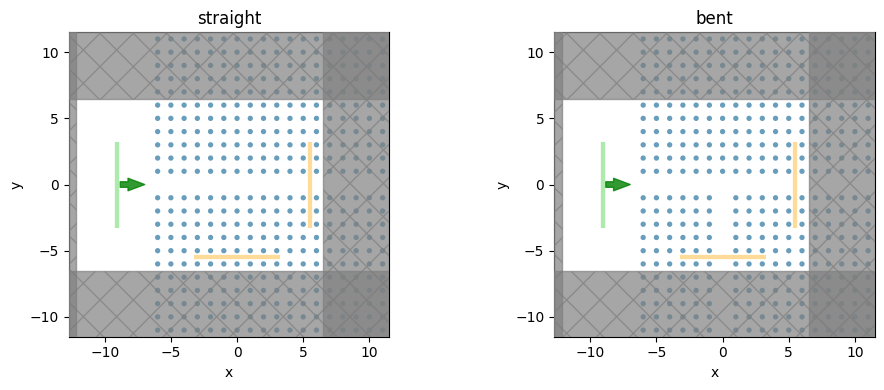

In [14]:
_, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
_ = sim_straight.plot(z=0.01, ax=ax1)
_ = sim_bent.plot(z=0.01, ax=ax2)
ax1.set_title('straight')
ax2.set_title('bent')

plt.show()

Next, we can run these two simulations to inspect the fields and compute some normalization.

In [15]:
sims0 = dict(straight=sim_straight, bent=sim_bent)
batch0 = web.Batch(simulations=sims0)
batch_data0 = batch0.run(path_dir='data')

Output()

18:41:55 EDT Started working on Batch containing 2 tasks.

18:42:00 EDT Maximum FlexCredit cost: 0.050 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

18:44:34 EDT Batch complete.

Output()

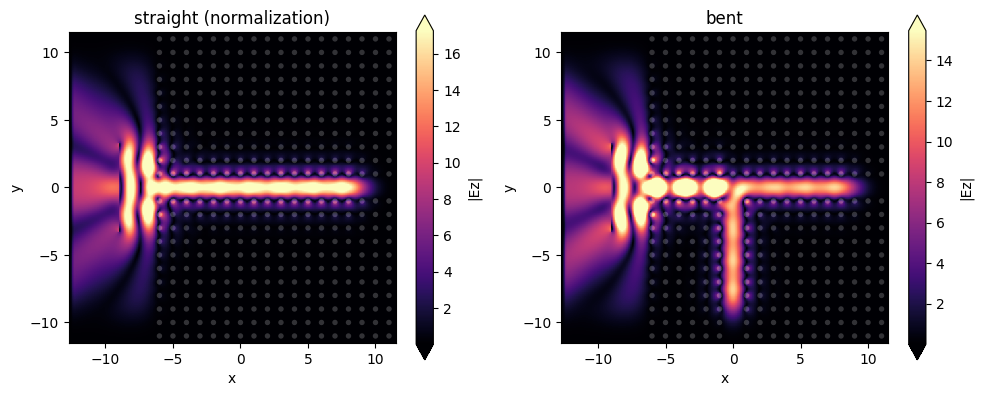

In [16]:
_, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
f = freq0
_ = batch_data0['straight'].plot_field("field", field_name="Ez", val="abs", f=freq0, ax=ax1)
_ = batch_data0['bent'].plot_field("field", field_name="Ez", val="abs", f=freq0, ax=ax2)
ax1.set_title('straight (normalization)')
ax2.set_title('bent')

plt.show()

Let's visualize the flux in both ports.

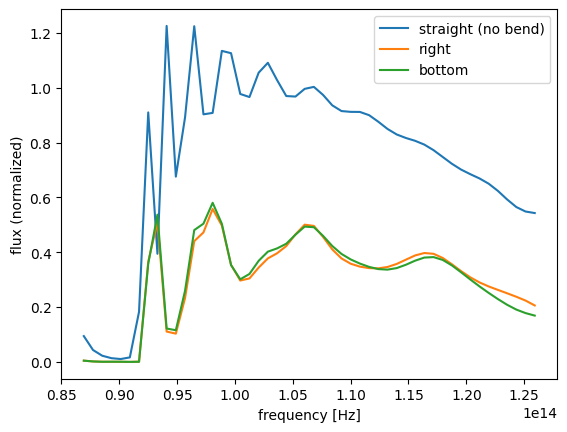

In [17]:
flux0_norm = abs(batch_data0['straight']['flux_x'].flux)
flux_straight = float(flux0_norm.interp(f=freq0).values)

flux0_bent_x = abs(batch_data0['bent']['flux_x'].flux)
flux0_bent_y = abs(batch_data0['bent']['flux_y'].flux)

flux0_x = flux0_bent_x / flux_straight
flux0_y = flux0_bent_y / flux_straight

(flux0_norm / flux_straight).plot(x='f', label='straight (no bend)')
flux0_x.plot(x='f', label='right')
flux0_y.plot(x='f', label='bottom')

plt.ylabel('flux (normalized)')
plt.legend()
plt.show()

We can see that the current design pretty evenly transmits flux to both the right and bottom ports.

## Optimization

Next, we will define our inverse design problem. We'll try to set the pillar radii in the design region to maximize flux in the -y port and minimize flux in the +x port. We can write this objective very simply as follows.

In [18]:
def objective(params: anp.ndarray) -> float:
    """Maximize flux in -y, minimize flux in +x."""
    
    sim = make_sim(params, has_bend=True, optimization_mode=True)
    sim_data = web.run(sim, task_name='phc_adjoint', verbose=False)
    
    flux_x = abs(anp.sum(sim_data['flux_x'].flux.values)) / flux_straight
    flux_y = abs(anp.sum(sim_data['flux_y'].flux.values)) / flux_straight

    # in the ideal case: flux_y = 1, flux_x = 0 -> objective = 1
    # in the worst case: flux_y = 0, flux_x = 1 -> objective = -1
    return flux_y - flux_x

As always, we can use one line of `autograd` code to get a function that gives the value and gradient of our objective when passed some parameters.

In [19]:
val_grad = autograd.value_and_grad(objective)

And then we can use this funtion in our gradient-ascent optimizer using `optax`.

We first set up the optimizer parameters.

In [20]:
import optax
from autograd.tracer import getval

# hyperparameters
num_steps = 15
learning_rate = 0.1

# initialize adam optimizer with starting parameters
params = np.array(params0).copy()
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)

# store history
objective_history = []
param_history = [params]
data_history = []

And then run the optimization in a for loop (note: to continue optimization, you can always re-run this cell assuming `params` is set to the last parameters from your previous run.

In [21]:
for i in range(num_steps):
    
    # compute gradient and current objective funciton value
    value, gradient = val_grad(params)

    gradient = np.array(gradient)

    # outputs
    print(f"step = {i + 1}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = optax.apply_updates(params, updates)

    # it is important using optax to convert the parameters back to numpy arrays to feed back to our gradient
    params = np.array(params)

    # save history
    objective_history.append(value)
    param_history.append(params)

step = 1
	J = -7.0341e-03
	grad_norm = 5.2121e+00
step = 2
	J = 1.6485e-01
	grad_norm = 4.8119e+00
step = 3
	J = 3.2632e-01
	grad_norm = 4.4957e+00
step = 4
	J = 4.7356e-01
	grad_norm = 3.9972e+00
step = 5
	J = 5.9443e-01
	grad_norm = 3.4097e+00
step = 6
	J = 6.8938e-01
	grad_norm = 3.0543e+00
step = 7
	J = 7.6372e-01
	grad_norm = 3.0075e+00
step = 8
	J = 8.3124e-01
	grad_norm = 2.9888e+00
step = 9
	J = 8.9607e-01
	grad_norm = 2.8254e+00
step = 10
	J = 9.5602e-01
	grad_norm = 2.5422e+00
step = 11
	J = 1.0107e+00
	grad_norm = 2.4249e+00
step = 12
	J = 1.0603e+00
	grad_norm = 2.5822e+00
step = 13
	J = 1.1108e+00
	grad_norm = 2.4194e+00
step = 14
	J = 1.1605e+00
	grad_norm = 1.9807e+00
step = 15
	J = 1.2041e+00
	grad_norm = 1.6587e+00


## Results

Let's inspect the results of the optimization.

The objective function increased steadily.

Text(0, 0.5, 'objective function')

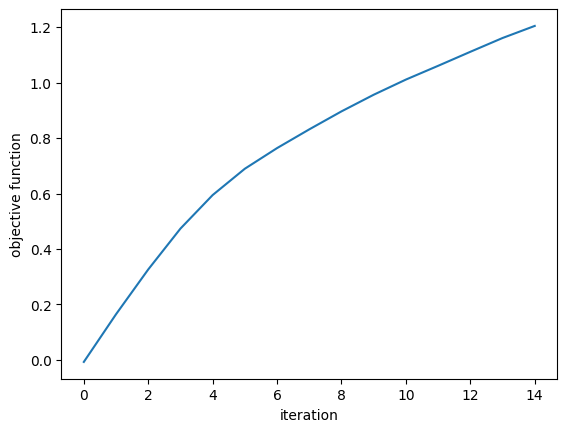

In [22]:
plt.plot(objective_history)
plt.xlabel('iteration')
plt.ylabel('objective function')

We can grab the last simulation from the parameter history and visualize the fields and flux values over the full spectrum.

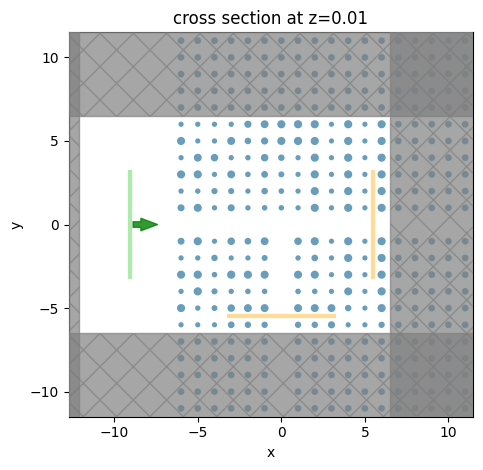

In [23]:
params_last = param_history[-1]

sim = make_sim(params_last, has_bend=True, optimization_mode=False)
_ = sim.plot(z=0.01)
plt.show()

In [24]:
sim_data = web.run(sim, task_name='phc')

19:39:08 EDT Created task 'phc' with task_id                                    
             'fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=772126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=584286;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\taskId]8;;\]8;id=772126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\=]8;;\]8;id=137119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\fdve]8;;\]8;id=772126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\-0660a6bd-dce]8;;\
             ]8;id=772126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\e-4631-af48-5b1f986e75b8']8;;\.

Output()

19:39:10 EDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

Output()

19:42:50 EDT status = success

             View simulation result at                                          
             ]8;id=546654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=821803;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\taskId]8;;\]8;id=546654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\=]8;;\]8;id=784008;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\fdve]8;;\]8;id=546654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\-0660a6bd-dce]8;;\
             ]8;id=546654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0660a6bd-dcee-4631-af48-5b1f986e75b8\e-4631-af48-5b1f986e75b8']8;;\.

Output()

19:42:54 EDT loading simulation from simulation_data.hdf5

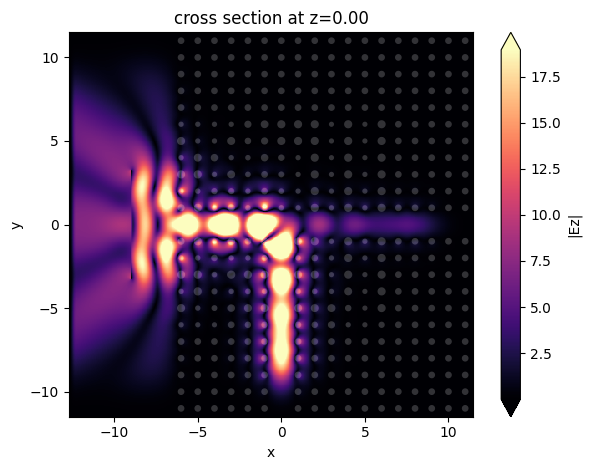

In [25]:
ax = sim_data.plot_field("field", field_name="Ez", val="abs", f=freq0)
plt.show()

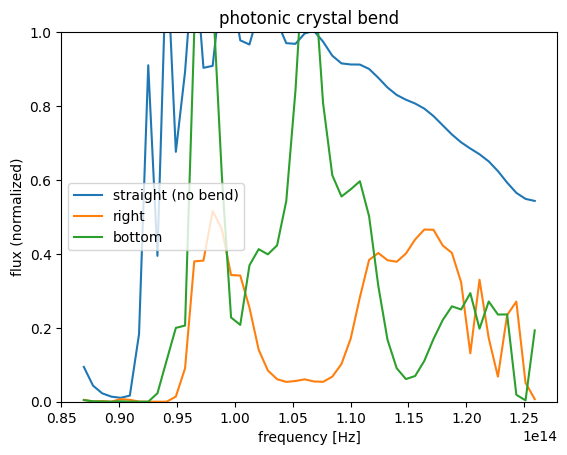

In [26]:
flux0_bent_x = abs(sim_data['flux_x'].flux)
flux0_bent_y = abs(sim_data['flux_y'].flux)

flux0_x = flux0_bent_x / flux_straight
flux0_y = flux0_bent_y / flux_straight

(flux0_norm / flux_straight).plot(x='f', label='straight (no bend)')
flux0_x.plot(x='f', label='right')
flux0_y.plot(x='f', label='bottom')

plt.ylim([0,1])
plt.ylabel('flux (normalized)')
plt.title('photonic crystal bend')
plt.legend()
plt.show()

We see from both the field plots and the flux plots that supresses the rightward flux while allowing transmission to the bottom port.